# Inteligencia Artificial 2026 - Lab 03

En este laboratorio vamos a diseñar redes neuronales *fully connected* en la librería `tensorflow.keras` para un problema de clasificación y un problema de regresión.

In [2]:
!pip install tensorflow

Defaulting to user installation because normal site-packages is not writeable
  Using cached tensorflow-2.21.0-cp313-cp313-win_amd64.whl.metadata (4.5 kB)
  Using cached absl_py-2.4.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached flatbuffers-25.12.19-py2.py3-none-any.whl.metadata (1.0 kB)
  Using cached gast-0.7.0-py3-none-any.whl.metadata (1.5 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-py2.py3-none-win_amd64.whl.metadata (5.3 kB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached protobuf-7.34.0-cp310-abi3-win_amd64.whl.metadata (595 bytes)
  Using cached termcolor-3.3.0-py3-none-any.whl.metadata (6.5 kB)
  Using cached wrapt-2.1.2-cp313-cp313-win_amd64.whl.metadata (7.6 kB)
  Using cached grpcio-1.78.0-cp313-cp313-win_amd64.whl.metadata (3.9 kB)
  Using cached keras-3.13.2-py3-none-any.whl.metadata (6.3 kB)
  Using c


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: C:\Users\Cindy\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [8]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-Learn
from sklearn.datasets import load_digits, fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, mean_squared_error, mean_absolute_error, r2_score

# TensorFlow y Keras
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical

# Configuración de estilo para gráficas
sns.set_theme(style="whitegrid")

### Ejercicio 1: Clasificación de Dígitos (Scikit-Learn digits)
Este ejercicio se centra en entender cómo una red neuronal "ve" patrones espaciales aplanados.

**Dataset:** `sklearn.datasets.load_digits()` contiene 1,797 muestras, 64 atributos.

**Objetivo:** Configurar la capa de salida y la función de pérdida para clasificación multiclase (10 dígitos).

**Instrucciones:**
* Normalizar los datos dividiendo por 16 (el valor máximo de los píxeles). Debe explicar las transformaciones que se están haciendo tanto al conjunto de datos, como a las etiquetas.

In [9]:
# Carga de datos
digits = load_digits()
X_digits = digits.data
y_digits = digits.target

# Partición de datos 
X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(
    X_digits, y_digits, test_size=0.2, random_state=42, stratify=y_digits
)

# 1. Normalización de los datos de entrada
X_train_d_norm = X_train_d / 16.0
X_test_d_norm = X_test_d / 16.0

# 2. Transformación de las etiquetas (One-Hot Encoding)
y_train_d_cat = to_categorical(y_train_d, num_classes=10)
y_test_d_cat = to_categorical(y_test_d, num_classes=10)

**Explicación de Transformaciones:**
* **Conjunto de datos (X):** Las imágenes originales tienen valores de píxeles que van de 0 a 16. Al dividir todo entre 16, normalizamos los datos a un rango de [0, 1]. Esto ayuda a que los gradientes durante el entrenamiento sean estables y la red neuronal converja más rápido.
* **Etiquetas (y):** Las etiquetas originales son enteros del 0 al 9. Se aplicó una transformación *One-Hot Encoding* (usando `to_categorical`), convirtiendo cada entero en un vector de tamaño 10 donde solo hay un '1' en la posición correspondiente a la clase, y '0' en el resto. Esto es necesario porque la capa de salida de nuestra red utilizará la función de activación Softmax para predecir probabilidades independientes para cada una de las 10 clases.
---


* Diseñar una arquitectura con al menos 2 capas ocultas. En cada capa, utilizar las funciones de activación adecuadas. Justifique la elección del número de capas y de neuronas, así como de las funciones de activación.

In [10]:
model_digits = Sequential([
    Dense(64, activation='relu', input_shape=(64,)), 
    Dense(32, activation='relu'),                    
    Dense(10, activation='softmax')                  
])

model_digits.summary()

C:\Users\Cindy\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,570 (25.66 KB)

 Trainable params: 6,570 (25.66 KB)

 Non-trainable params: 0 (0.00 B)

**Justificación de la Arquitectura:**
* **Capas y Neuronas:** Se eligieron 2 capas ocultas. La primera con 64 neuronas (coincidiendo con los 64 atributos de entrada para capturar características iniciales) y una segunda de 32 neuronas para comprimir la representación aprendida (reducción de dimensionalidad progresiva). La capa de salida tiene exactamente 10 neuronas porque el objetivo es clasificar 10 dígitos distintos.
* **Funciones de Activación:** En las capas ocultas se utilizó **ReLU**, ya que mitiga el problema del desvanecimiento del gradiente y permite un entrenamiento más rápido. En la capa de salida se utilizó **Softmax**, obligatoria para problemas de clasificación multiclase, ya que transforma las salidas en una distribución de probabilidades que suman 1.
---

* Elegir la función de pérdida apropiada, así como los hiper-parámetros que considere más adecuados. Justifique la elección de estos hiper-parámetros.

In [11]:
model_digits.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


history_digits = model_digits.fit(
    X_train_d_norm, y_train_d_cat,
    epochs=50,
    batch_size=32,
    validation_split=0.1, 
    verbose=1
)

Epoch 1/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.3171 - loss: 2.1164 - val_accuracy: 0.5208 - val_loss: 1.8528
Epoch 2/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6744 - loss: 1.5368 - val_accuracy: 0.7569 - val_loss: 1.2125
Epoch 3/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8360 - loss: 0.9014 - val_accuracy: 0.8889 - val_loss: 0.6830
Epoch 4/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9041 - loss: 0.5254 - val_accuracy: 0.9236 - val_loss: 0.4446
Epoch 5/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9250 - loss: 0.3652 - val_accuracy: 0.9444 - val_loss: 0.3355
Epoch 6/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9428 - loss: 0.2842 - val_accuracy: 0.9097 - val_loss: 0.3042
Epoch 7/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9528 - loss: 0.2327 - val_accuracy: 0.9306 - val_loss: 0.2556
Epoch 8/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9582 - loss: 0.1991 - val_accuracy: 0.9375 - val_loss:

**Justificación de Hiper-parámetros:**
* **Función de pérdida:** Se utilizó `categorical_crossentropy` porque es la estándar matemática para clasificación multiclase con etiquetas en formato One-Hot. Penaliza fuertemente predicciones con alta confianza hacia la clase incorrecta.
* **Optimizador y Learning Rate:** Se utilizó **Adam** con un *learning rate* de $\alpha = 0.001$. Adam combina las ventajas de AdaGrad y RMSProp, ajustando dinámicamente el ratio de aprendizaje. 0.001 es el valor inicial recomendado por defecto que suele ofrecer buena convergencia.
* **Epochs y Batch Size:** Se fijaron 50 *epochs*, suficientes para que este dataset pequeño converja. El *batch size* se fijó en 32, ofreciendo un buen equilibrio entre uso de memoria, velocidad y regularización del gradiente estocástico.
---

* Mostrar una Matriz de Confusión usando seaborn para identificar qué números confunde la red (comúnmente debería ser el 1 con el 7 o el 3 con el 8).


12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


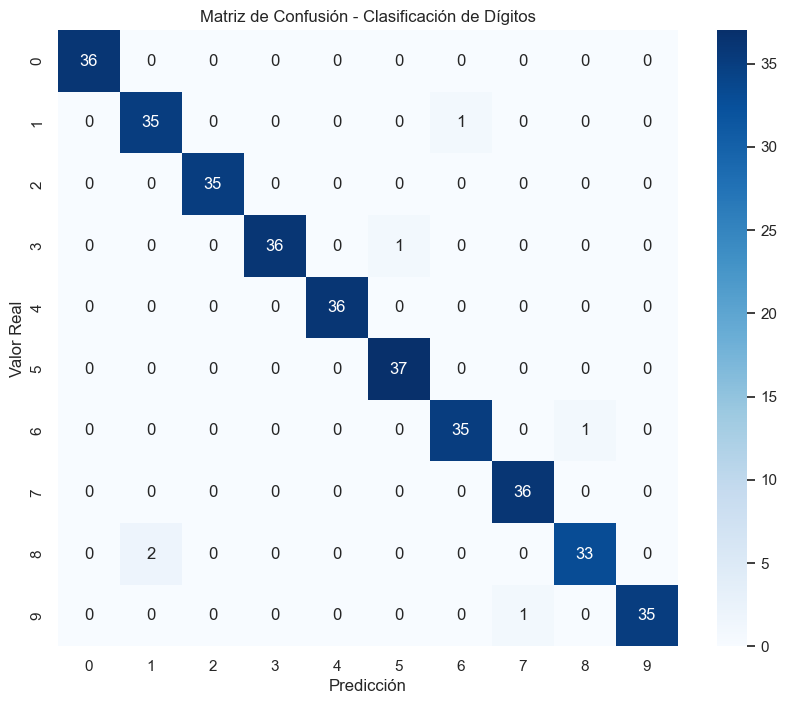

In [ ]:
y_pred_d_probs = model_digits.predict(X_test_d_norm)
y_pred_d_classes = np.argmax(y_pred_d_probs, axis=1)

cm = confusion_matrix(y_test_d, y_pred_d_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=digits.target_names, yticklabels=digits.target_names)
plt.title('Matriz de Confusión - Clasificación de Dígitos')
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.show()

* Muestre un conjunto de métricas de desempeño (tanto en entrenamiento como en test), para determinar la efectividad de su clasificador. Muestre 5 ejemplos de imágenes bien clasificadas y 5 ejemplos de imágenes mal clasificadas.